1. 데이터프레임 및 정답 라벨링 생성 중...
✅ 초기 라벨 분포 (0:정상, 1:열화, 2:까만배경, 3:너무밝음)
label
0    191
1    198
2    308
3     20
Name: count, dtype: int64

2. DINOv2 모델 로드 및 Feature 추출 시작...


100%|██████████| 2/2 [00:13<00:00,  6.60s/it]



3. 데이터 분할 및 3번 클래스(너무밝음) 오버샘플링 중...
✅ 오버샘플링 완료! 증폭된 학습 데이터 분포: [153 158 246 208]

4. 🚀 선형 분류기 초고속 학습 시작
Epoch [  1/200] Loss: 1.0502 | Test Acc: 88.19%
Epoch [ 50/200] Loss: 0.0568 | Test Acc: 93.06%
Epoch [100/200] Loss: 0.0457 | Test Acc: 95.14%
Epoch [150/200] Loss: 0.0396 | Test Acc: 97.22%
Epoch [200/200] Loss: 0.0360 | Test Acc: 97.22%

✅ 최종 학습 완료! 최고 Test 정확도: 97.22%

5. 📊 Test 세트 상세 평가 결과 출력

[Classification Report]
              precision    recall  f1-score   support

   Normal(0)       0.93      1.00      0.96        38
 Degraded(1)       1.00      0.97      0.99        40
    Black(2)       1.00      0.95      0.98        62
   Bright(3)       0.80      1.00      0.89         4

    accuracy                           0.97       144
   macro avg       0.93      0.98      0.95       144
weighted avg       0.98      0.97      0.97       144



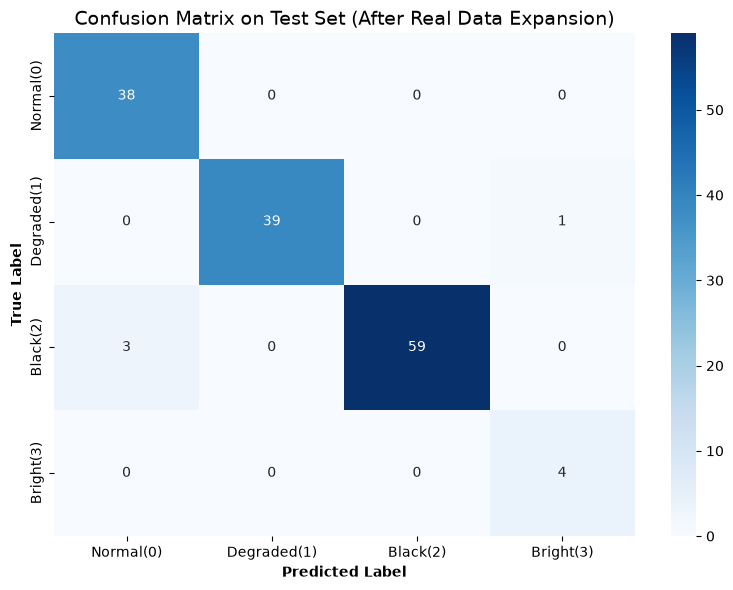

In [6]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 사용자 정의 모듈 (가정)
from load_model import get_cell_dino_model

# ==========================================
# 1. 데이터프레임 생성 및 정답(Label) 할당
# ==========================================
print("1. 데이터프레임 및 정답 라벨링 생성 중...")
csv_path = "../data/png_converted/NCI60_Images.csv"
data_dir = Path("../data/png_converted")

# 1-1. 전체 원본 데이터 로드
raw_df = pd.read_csv(csv_path)

# 1-2. 기존 클래스들(1, 2, 3)을 위한 데이터 (nybd1 조건 포함)
mask_nybd1 = (raw_df['channel'] != 'hoechst') & (raw_df['compound'].str.contains('nybd1', na=False))
df_nybd1 = raw_df[mask_nybd1]

noise_df = df_nybd1[df_nybd1['mean'] > 100.0].reset_index(drop=True)
mask_good = (df_nybd1['mean'].between(25, 50, inclusive='neither')) & (df_nybd1['sbr'].between(2, 5, inclusive='neither'))
good_df = df_nybd1[mask_good].reset_index(drop=True)
mask_black = (df_nybd1['mean'].between(0,10, inclusive='neither'))
black_df = df_nybd1[mask_black].reset_index(drop=True)
mask_black2 = df_nybd1['sbr'].between(10, 20, inclusive='neither')
black2_df = df_nybd1[mask_black2].reset_index(drop=True)

# 1-3. ⭐️ 새로 추가하신 'Bright' 클래스 전용 데이터 (전체 화합물 대상)
mask_all = (raw_df['channel'] != 'hoechst')
df_all = raw_df[mask_all]
bright_df = df_all[df_all['mean'] > 125.0].reset_index(drop=True)

# 슬라이싱 및 복사
noise_eval = noise_df.iloc[:200].copy()
good_eval = good_df.iloc[:200].copy()
black_eval = black_df.iloc[:200].copy()
black2_eval = black2_df.iloc[:100].copy()

# ⭐️ 추가로 찾아낸 진짜 밝은 이미지들 추출
real_bright_indices = [0, 1, 3, 4, 5, 66, 67, 68, 69, 70, 71, 74, 75, 76, 77, 78, 79]
bright_eval = bright_df.loc[real_bright_indices].copy()

# 기본 라벨 할당
noise_eval['label'] = 2
good_eval['label'] = 1
black_eval['label'] = 3
black2_eval['label'] = 3
bright_eval['label'] = 4 # 새로운 4번 클래스 뭉치

# 기존에 수동으로 확인했던 예외 처리 유지
noise_eval.loc[[67, 68], 'label'] = 4
good_exceptions = [8, 34, 40, 42, 47, 49, 74, 131, 132, 142, 143, 152, 157, 173]
good_eval.loc[good_exceptions, 'label'] = 3
black2_eval.loc[[0, 2, 35, 36, 96], 'label'] = 1
black2_eval.loc[[48], 'label'] = 4

# 통합 데이터프레임 병합
dataset_df = pd.concat([noise_eval, good_eval, black_eval, black2_eval, bright_eval], ignore_index=True)
dataset_df = dataset_df.sample(frac=1, random_state=42).reset_index(drop=True)

# PyTorch를 위한 타겟 변환 (1,2,3,4 -> 0,1,2,3)
dataset_df['label'] = dataset_df['label'] - 1
print(f"✅ 초기 라벨 분포 (0:정상, 1:열화, 2:까만배경, 3:너무밝음)\n{dataset_df['label'].value_counts().sort_index()}")

# ==========================================
# 2. PyTorch Dataset 생성 및 DINOv2 Feature 추출
# ==========================================
class CellEvalDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        rel_path = str(self.dataframe.loc[idx, 'rel_path'])
        label = self.dataframe.loc[idx, 'label']
        img_path = self.root_dir / rel_path
        
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

eval_dataset = CellEvalDataset(dataset_df, data_dir, transform=transform)

# ⚠️ num_workers=0 설정 (공유 메모리 부족으로 인한 Bus Error 방지)
eval_dataloader = DataLoader(eval_dataset, batch_size=512, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\n2. DINOv2 모델 로드 및 Feature 추출 시작...")
dino_model = get_cell_dino_model().to(device)
dino_model.eval()

all_features = []
all_labels = []

with torch.inference_mode():
    for images, labels in tqdm(eval_dataloader):
        images = images.to(device)
        features = dino_model(images)
        all_features.append(features.cpu().float().numpy())
        all_labels.extend(labels.numpy())

X_all = np.concatenate(all_features, axis=0)
y_all = np.array(all_labels)

# ==========================================
# 3. Train / Test Split 및 불균형 해결 (Oversampling)
# ==========================================
print("\n3. 데이터 분할 및 3번 클래스(너무밝음) 오버샘플링 중...")
X_train, X_test, y_train, y_test = train_test_split(
    X_all, 
    y_all, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_all
)

# 3번 클래스 데이터 증폭 (Oversampling)
bright_indices = np.where(y_train == 3)[0]
if len(bright_indices) > 0:
    # ⭐️ 핵심 변경점: 데이터가 20장으로 늘어났으므로 150배 뻥튀기를 하면 3000장이 되어버림.
    # 다른 클래스(약 200장)에 맞춰서 유동적으로 배수를 계산하도록 수정
    num_repeats = max(1, 200 // len(bright_indices)) 
    
    X_train_bright_copies = np.repeat(X_train[bright_indices], num_repeats, axis=0)
    y_train_bright_copies = np.repeat(y_train[bright_indices], num_repeats, axis=0)

    X_train = np.vstack([X_train, X_train_bright_copies])
    y_train = np.concatenate([y_train, y_train_bright_copies])
    
print(f"✅ 오버샘플링 완료! 증폭된 학습 데이터 분포: {np.bincount(y_train)}")

# 텐서 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 512
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

# ==========================================
# 4. 분류기(Head) 정의 및 학습 (Weighted Loss 포함)
# ==========================================
class ClassifierHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.head(x)

in_features = X_train_tensor.shape[1]
num_classes = len(np.unique(y_all))

classifier = ClassifierHead(in_features, num_classes).to(device)

# 가중치 역수 계산 (증폭된 데이터 기준)
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

# 오버샘플링과 Loss 가중치를 동시에 적용하여 소수 클래스 집중 학습
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(classifier.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 200
best_acc = 0.0
best_model_state = None

print(f"\n4. 🚀 선형 분류기 초고속 학습 시작")

for epoch in range(epochs):
    # --- Train ---
    classifier.train()
    total_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = classifier(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()
        
    train_loss = total_loss / len(X_train_tensor)
    
    # --- Validation ---
    classifier.eval()
    correct_test, total_test = 0, 0
    
    with torch.inference_mode():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = classifier(inputs)
            
            _, predicted = torch.max(outputs, 1)
            total_test += targets.size(0)
            correct_test += (predicted == targets).sum().item()
            
    test_acc = correct_test / total_test * 100
    
    # 최고 성능 달성 시 가중치 저장
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_state = copy.deepcopy(classifier.state_dict())
        
    # 50 에폭마다 결과 출력
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}%")

# 최고 성능 모델로 복구
classifier.load_state_dict(best_model_state)
print(f"\n✅ 최종 학습 완료! 최고 Test 정확도: {best_acc:.2f}%")

# ==========================================
# 5. 최종 성능 평가 (Confusion Matrix & Report)
# ==========================================
print("\n5. 📊 Test 세트 상세 평가 결과 출력")
classifier.eval()
all_preds = []
all_targets = []

with torch.inference_mode():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = classifier(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

class_names = ['Normal(0)', 'Degraded(1)', 'Black(2)', 'Bright(3)']

# 상세 성능 리포트 (Precision, Recall 등)
print("\n[Classification Report]")
print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set (After Real Data Expansion)', fontsize=14)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

차원 축소(UMAP) 진행 중...


/workspace/miniconda3/envs/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


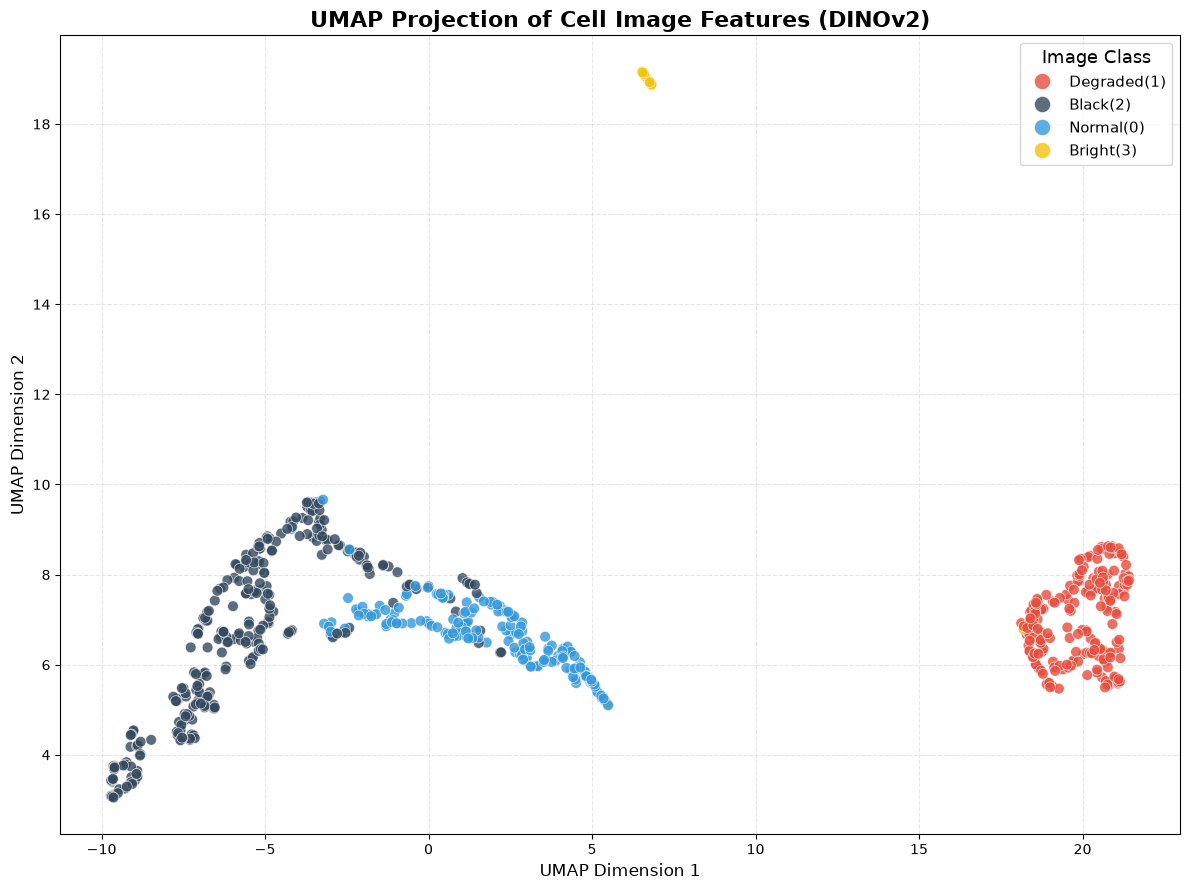

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# ==========================================
# UMAP 차원 축소 (표준 CPU 방식)
# ==========================================
print("차원 축소(UMAP) 진행 중...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_all)

# ==========================================
# 시각화를 위한 데이터프레임 구성
# ==========================================
umap_df = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
umap_df['Label'] = y_all

# 정수 라벨을 알아보기 쉬운 문자열로 매핑
label_mapping = {
    0: 'Normal(0)', 
    1: 'Degraded(1)', 
    2: 'Black(2)', 
    3: 'Bright(3)'
}
umap_df['Class'] = umap_df['Label'].map(label_mapping)

# 클래스별로 직관적인 색상 지정 
# 정상: 파랑, 열화: 빨강, 까만배경: 짙은 회색, 너무밝음: 노랑(골드)
custom_palette = {
    'Normal(0)': '#3498db',
    'Degraded(1)': '#e74c3c',
    'Black(2)': '#34495e',
    'Bright(3)': '#f1c40f'
}

# ==========================================
# Scatter Plot 그리기
# ==========================================
plt.figure(figsize=(12, 9))
sns.scatterplot(
    data=umap_df,
    x='UMAP_1', 
    y='UMAP_2',
    hue='Class',
    palette=custom_palette,
    s=60,            # 점 크기
    alpha=0.8,       # 투명도
    edgecolor='w',   # 점 테두리 (가독성 향상)
    linewidth=0.5
)

# 그래프 꾸미기
plt.title("UMAP Projection of Cell Image Features (DINOv2)", fontsize=16, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)

# 범례(Legend) 위치 조정
plt.legend(title='Image Class', title_fontsize='13', fontsize='11', loc='best', markerscale=1.5)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np

# ==========================================
# 1. 원본 데이터 로드 및 추론 대상 필터링
# ==========================================
print("1. 데이터 로드 및 추론 준비 중...")
csv_path = "../data/png_converted/NCI60_Images.csv"
data_dir = Path("../data/png_converted")

# 원본 데이터 불러오기
raw_df = pd.read_csv(csv_path)

# 'label' 열을 미리 None으로 초기화 (hoechst는 계속 None으로 남게 됨)
raw_df['label'] = None
raw_df['label_name'] = None # 확인하기 쉽게 문자열 라벨도 추가

# hoechst를 제외한 추론 대상 이미지 분리 
# (원본 데이터프레임의 인덱스를 기억하기 위해 reset_index(drop=False) 사용)
inference_mask = raw_df['channel'] != 'hoechst'
inference_df = raw_df[inference_mask].copy().reset_index(drop=False)

print(f"-> 전체 데이터: {len(raw_df)}장 | 추론 대상 데이터: {len(inference_df)}장 | 제외된 hoechst: {len(raw_df) - len(inference_df)}장")

# ==========================================
# 2. 추론용 Dataset 및 DataLoader 구성
# ==========================================
class InferenceDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        rel_path = str(self.dataframe.loc[idx, 'rel_path'])
        orig_idx = self.dataframe.loc[idx, 'index'] # 원본 raw_df에서의 행 번호
        img_path = self.root_dir / rel_path
        
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
            
        return image, orig_idx

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

# 메모리 초과(Bus Error) 방지를 위해 num_workers=0 설정
infer_dataset = InferenceDataset(inference_df, data_dir, transform=transform)
infer_loader = DataLoader(infer_dataset, batch_size=512, shuffle=False, num_workers=0)

# ==========================================
# 3. 전체 이미지 DINOv2 통과 및 라벨 예측
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 기존에 학습된 모델들이 메모리에 있는지 확인 (평가 모드로 전환)
dino_model.eval()
classifier.eval()

predictions = []
original_indices = []

print("\n2. 🚀 전체 이미지 라벨 예측 시작 (DINOv2 + Linear Classifier)...")
with torch.inference_mode():
    for images, orig_idxs in tqdm(infer_loader):
        images = images.to(device)
        
        # 1. DINOv2 특징 추출
        features = dino_model(images)
        
        # 2. 선형 분류기를 통한 클래스 예측
        outputs = classifier(features)
        _, preds = torch.max(outputs, 1)
        
        predictions.extend(preds.cpu().numpy())
        original_indices.extend(orig_idxs.numpy())

# ==========================================
# 4. 원본 DataFrame에 병합 및 저장
# ==========================================
print("\n3. 예측 결과를 원본 데이터에 병합 및 CSV 저장 중...")

# 원래 인덱스 위치에 예측된 정수 라벨(0, 1, 2, 3) 덮어쓰기
raw_df.loc[original_indices, 'label'] = predictions

# 숫자만 보면 헷갈릴 수 있으므로 문자열 라벨 이름도 같이 매핑
label_mapping = {
    0: 'Normal', 
    1: 'Degraded', 
    2: 'Black', 
    3: 'Bright'
}
raw_df['label_name'] = raw_df['label'].map(label_mapping)

# 새로운 CSV 파일로 저장
save_path = "../data/png_converted/NCI60_Images_labeled.csv"
raw_df.to_csv(save_path, index=False)

print(f"✅ 모든 작업 완료! 라벨이 추가된 파일이 '{save_path}'에 저장되었습니다.")

# 결과 요약 출력
print("\n📊 [전체 데이터 예측 결과 요약]")
print(raw_df['label_name'].value_counts(dropna=False))

1. 데이터 로드 및 추론 준비 중...
-> 전체 데이터: 34696장 | 추론 대상 데이터: 30297장 | 제외된 hoechst: 4399장

2. 🚀 전체 이미지 라벨 예측 시작 (DINOv2 + Linear Classifier)...


100%|██████████| 60/60 [22:50<00:00, 22.83s/it]



3. 예측 결과를 원본 데이터에 병합 및 CSV 저장 중...
✅ 모든 작업 완료! 라벨이 추가된 파일이 '../data/png_converted/NCI60_Images_labeled.csv'에 저장되었습니다.

📊 [전체 데이터 예측 결과 요약]
label_name
Normal      16885
Black        7359
Degraded     5288
NaN          4399
Bright        765
Name: count, dtype: int64
